<a href="https://colab.research.google.com/github/renealejrdzcst-spec/IA-Verano-2026-Ren-Rdz/blob/main/Assignments/FFNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5.- Artificial Neural Network: feedforward.
Artificial Intelligence

**Authors:**
- Eugenio Espronceda Acosta
- René Alejandro Rodríguez Castañeda
- Manuel Alejandro Juárez Grimaldo

**Student IDs:**
- 2096538
- 2019068
- 2115290

**Class Schedule: V4**

**Group** 001

## 1. Load libraries

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input

## 2. Load Data
The load_data() function from Keras is used to obtain the training and test sets with the default split.

In [11]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

print("Training shape:", train_data.shape)
print("Test shape:", test_data.shape)

Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## 3. Data Preprocessing
Pixel values are normalized (0-255 -> 0-1) and the labels are encoded in One-Hot format, since the output layer will use the softmax activation function.

In [12]:
# Normalize Images
train_data = train_data.astype("float32") / 255.0
test_data = test_data.astype("float32") / 255.0

# Convert labels to One-Hot Encoding
train_labels_cat = to_categorical(train_labels)
test_labels_cat = to_categorical(test_labels)

# Verify preprocessing
print("Pixel range after normalization:", train_data.min(), "-", train_data.max())
print("Original label example:", train_labels[0])
print("One-Hot encoded label example:", train_labels_cat[0])

Pixel range after normalization: 0.0 - 1.0
Original label example: 5
One-Hot encoded label example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 4. Model Selection and Training
A feedforward neural network (MLP) is proposed with two hidden layers using relu activation and an output layer with softmax activation (10 classes). It is compiled with the adam optimizer, categorical_crossentropy loss function, and accuracy metric. Training is performed using Keras's fit() function.

In [13]:
# Architecture construction
model = Sequential()
model.add(Input(shape=(28,28)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

# Model compilation
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Training
history = model.fit(
    train_data,
    train_labels_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9240 - loss: 0.2618 - val_accuracy: 0.9649 - val_loss: 0.1257
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9660 - loss: 0.1098 - val_accuracy: 0.9656 - val_loss: 0.1129
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9759 - loss: 0.0769 - val_accuracy: 0.9712 - val_loss: 0.0916
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9824 - loss: 0.0567 - val_accuracy: 0.9697 - val_loss: 0.1056
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9861 - loss: 0.0443 - val_accuracy: 0.9734 - val_loss: 0.0974
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9875 - loss: 0.0372 - val_accuracy: 0.9660 - val_loss: 0.1346
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9907 - loss: 0.0301 - val_accuracy: 0.9723 - val_loss: 0.1011
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9924 - loss: 0.0235 - 

## 5. Model Testing
The model is evaluated on the test set (test_data) using evaluate(), and 5 predictions are made, showing the predicted value alongside the actual value.

In [14]:
# Model evaluation with the test set
loss, accuracy = model.evaluate(test_data, test_labels_cat)
print("\nTest data accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9784 - loss: 0.0933

Test data accuracy: 0.9783999919891357


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Image 0
Prediction: 7
Real Value: 7
---------------------------
Image 35
Prediction: 2
Real Value: 2
---------------------------
Image 145
Prediction: 1
Real Value: 1
---------------------------
Image 600
Prediction: 6
Real Value: 6
---------------------------
Image 1000
Prediction: 9
Real Value: 9
---------------------------


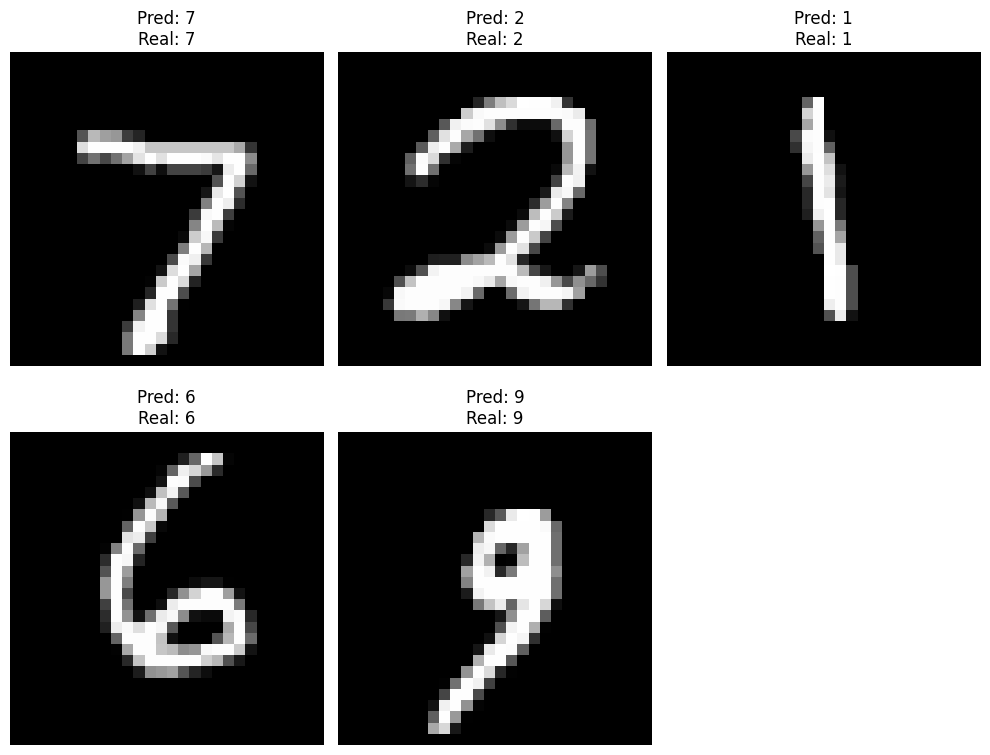

In [15]:
# Five predictions with the test set
predictions = model.predict(test_data)
indices = [0, 35, 145, 600, 1000]

plt.figure(figsize=(10, 8))
for i, indice in enumerate(indices):
    plt.subplot(2, 3, i + 1)
    plt.imshow(test_data[indice], cmap='gray')
    pred = np.argmax(predictions[indice])
    real = test_labels[indice]
    plt.title(f"Pred: {pred}\nReal: {real}")
    plt.axis("off")

    print(f"Image {indice}")
    print(f"Prediction: {pred}")
    print(f"Real Value: {real}")
    print("---------------------------")

plt.tight_layout()
plt.show()

Note

It was decided to use Keras instead of scikit-learn because, although the assignment mentions the "fit()" function from scikit-learn, the rest of the assignment is built entirely around Keras: the dataset is loaded using the load_data() function from this library, and it explicitly requires the output layer to use the softmax activation function, something that is defined directly in the model's architecture in Keras, whereas in scikit-learn (MLPClassifier) that activation is applied automatically and internally, without being able to configure or explicitly display it in the code. In addition, with Keras it is possible to propose and control the entire structure of the network layer by layer, as the assignment requires, something that scikit-learn does not allow with the same level of detail.